In [26]:
import intake
cat = intake.open_catalog("https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml")["online"]

In [37]:
ds = cat["ERA5"](zoom=8).to_dask()

/home/users/mmuetz/miniforge3/envs/hackathon_base_env/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [39]:
print(ds.time.values)
import numpy as np
print(np.diff(ds.time) / 86400e9) # print time diffs+convert ns to days.


['1940-01-01T00:00:00.000000000' '1940-02-01T00:00:00.000000000'
 '1940-03-01T00:00:00.000000000' ... '2023-10-01T00:00:00.000000000'
 '2023-11-01T00:00:00.000000000' '2023-12-01T00:00:00.000000000']
[31 29 31 ... 30 31 30]


In [4]:
import easygems.healpix as egh

In [5]:
ds.time

<xarray.DataArray 'time' (time: 1008)> Size: 8kB
array(['1940-01-01T00:00:00.000000000', '1940-02-01T00:00:00.000000000',
       '1940-03-01T00:00:00.000000000', ..., '2023-10-01T00:00:00.000000000',
       '2023-11-01T00:00:00.000000000', '2023-12-01T00:00:00.000000000'],
      shape=(1008,), dtype='datetime64[ns]')
Coordinates:
    crs      float32 4B ...
  * time     (time) datetime64[ns] 8kB 1940-01-01 1940-02-01 ... 2023-12-01
Attributes:
    axis:     T

<Figure size 640x480 with 0 Axes>

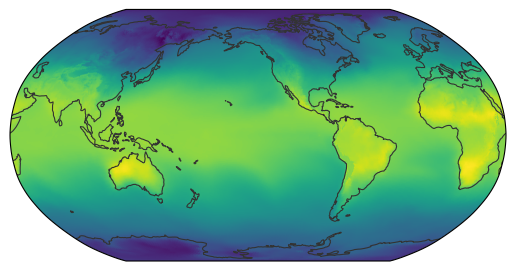

In [12]:
egh.healpix_show(ds.sel(time='2023-11-01', level=950).t)

In [19]:
for n in ds.data_vars:
    v = ds[n]
    print(v.name, v.long_name)

100u 100 metre U wind component
100v 100 metre V wind component
10fg 10 metre wind gust since previous post-processing
10si 10 metre wind speed
10u 10 metre U wind component
10v 10 metre V wind component
2d 2 metre dewpoint temperature
2t 2 metre temperature
asn Snow albedo
bld Boundary layer dissipation
blh Boundary layer height
cape Convective available potential energy
cbh Cloud base height
cc Fraction of cloud cover
cdir Clear-sky direct solar radiation at surface
ci Sea ice area fraction
ciwc Specific cloud ice water content
clwc Specific cloud liquid water content
cp Convective precipitation
crr Convective rain rate
crwc Specific rain water content
csf Convective snowfall
csfr Convective snowfall rate water equivalent
cswc Specific snow water content
d Divergence
e Evaporation
es Snow evaporation
ewss Eastward turbulent surface stress
fal Forecast albedo
fdir Total sky direct solar radiation at surface
flsr Forecast logarithm of surface roughness for heat
fsr Forecast surface rou

<Figure size 640x480 with 0 Axes>

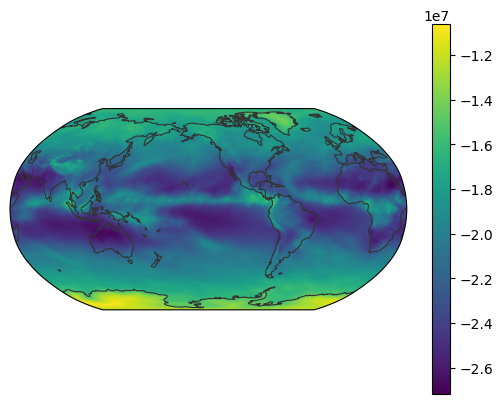

In [25]:
import matplotlib.pyplot as plt
im = egh.healpix_show(ds.sel(time='2023-10-01', level=950).ttr)
plt.colorbar(im)

In [36]:
ds

<xarray.Dataset> Size: 545GB
Dimensions:  (time: 1008, cell: 196608, level: 37)
Coordinates:
  * cell     (cell) float32 786kB 0.0 1.0 2.0 ... 1.966e+05 1.966e+05 1.966e+05
    crs      float32 4B ...
    lat      (cell) float32 786kB dask.array<chunksize=(196608,), meta=np.ndarray>
  * level    (level) float32 148B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
    lon      (cell) float32 786kB dask.array<chunksize=(196608,), meta=np.ndarray>
  * time     (time) datetime64[ns] 8kB 1940-01-01 1940-02-01 ... 2023-12-01
Data variables: (12/111)
    100u     (time, cell) float32 793MB dask.array<chunksize=(24, 16384), meta=np.ndarray>
    100v     (time, cell) float32 793MB dask.array<chunksize=(24, 16384), meta=np.ndarray>
    10fg     (time, cell) float32 793MB dask.array<chunksize=(24, 16384), meta=np.ndarray>
    10si     (time, cell) float32 793MB dask.array<chunksize=(24, 16384), meta=np.ndarray>
    10u      (time, cell) float32 793MB dask.array<chunksize=(24, 16384), meta=np.ndarray>
    10v      (time, cell) float32 793MB dask.array<chunksize=(24, 16384), meta=np.ndarray>
    ...       ...
    uvb      (time, cell) float32 793MB dask.array<chunksize=(24, 16384), meta=np.ndarray>
    v        (time, level, cell) float32 29GB dask.array<chunksize=(24, 4, 4096), meta=np.ndarray>
    vo       (time, level, cell) float32 29GB dask.array<chunksize=(24, 4, 4096), meta=np.ndarray>
    w        (time, level, cell) float32 29GB dask.array<chunksize=(24, 4, 4096), meta=np.ndarray>
    z        (time, level, cell) float32 29GB dask.array<chunksize=(24, 4, 4096), meta=np.ndarray>
    zust     (time, cell) float32 793MB dask.array<chunksize=(24, 16384), meta=np.ndarray>
Attributes:
    acknowledgment:  Contains modified Copernicus Climate Change Service info...
    contact:         lukas.kluft@mpimet.mpg.de
    creator:         Lukas Kluft
    description:     HEALPixelation of ERA5
    source:          Post-processed dataset based on the ERA5 mirror located ...